In [1]:
from fealpy.backend import backend_manager as bm
from fealpy.backend import TensorLike

from fealpy.mesh import UniformMesh2d
from fealpy.functionspace.lagrange_fe_space import LagrangeFESpace
from fealpy.decorator import cartesian
from fealpy.fem import BilinearForm, ScalarDiffusionIntegrator
from fealpy.fem import LinearForm, ScalarSourceIntegrator
from fealpy.fem import DirichletBC
from fealpy.solver import cg

import numpy as np


In [2]:
data = np.load("kf_quad.npz")

sample_id = 0

points = data["points"]
weights = data["quad_weights"]

k = data["k"][sample_id]
f = data["f"][sample_id]

print("points:", points.shape)
print("weights:", weights.shape)
print("k:", k.shape)
print("f:", f.shape)

points: (10000, 16, 2)
weights: (16,)
k: (10000, 16)
f: (10000, 16)


In [3]:
device = 'cpu'

bm.set_backend('pytorch')
bm.set_default_device(device)
dtype = bm.float32

In [4]:
k = bm.tensor(k, dtype=dtype, device=device)
f = bm.tensor(f, dtype=dtype, device=device)

In [5]:
class Exp1():
    def __init__(self, dtype = bm.float32):
        self.domain = [0, 1, 0, 1]
        self.dtype = dtype
    
    @cartesian
    def dirichlet(self, p: TensorLike) -> TensorLike:
        """Dirichlet boundary condition"""
        x = p[..., 0]
        return bm.zeros(x.shape, dtype=self.dtype)

In [6]:
PDE = Exp1()

domain = PDE.domain
nx, ny = 100, 100

hx = (domain[1] - domain[0])/nx
hy = (domain[3] - domain[2])/ny

mesh = UniformMesh2d((0, nx, 0, ny), h=(hx, hy), origin=(domain[0], domain[2]), ftype=bm.float32)


c:\Users\Rainbow\.conda\envs\eit\Lib\site-packages\torch\utils\_device.py:106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
c:\Users\Rainbow\.conda\envs\eit\Lib\site-packages\torch\utils\_device.py:106: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  return func(*args, **kwargs)


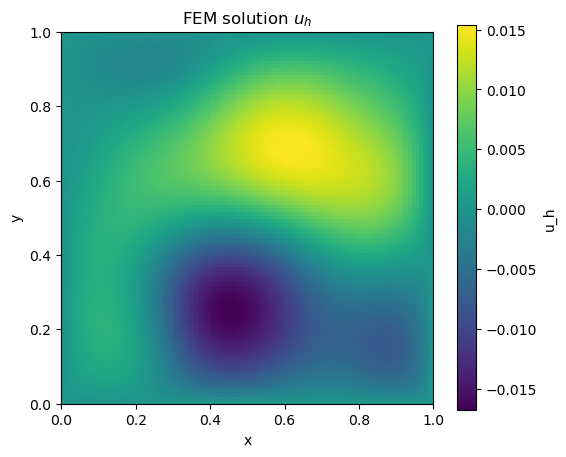

In [7]:
space= LagrangeFESpace(mesh, p=1)
uh = space.function()
bform = BilinearForm(space)
DI = ScalarDiffusionIntegrator(k)
bform.add_integrator(DI)

lform = LinearForm(space)
SI = ScalarSourceIntegrator(f)
lform.add_integrator(SI)

A = bform.assembly()
F = lform.assembly()

A, F = DirichletBC(space, gd=PDE.dirichlet).apply(A, F)
uh[:] = cg(A, F, maxit=5000, atol=1e-14, rtol=1e-14)

import matplotlib.pyplot as plt

uh_2d = uh.reshape(nx + 1, ny + 1)

plt.figure(figsize=(6, 5))
plt.imshow(
    uh_2d.T,              # 转置一下，让 x/y 方向显示更自然
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(label="u_h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("FEM solution $u_h$")
plt.show()

In [8]:
import sys
import numpy as np
import torch
from torch import nn

# 你的脚本所在目录
sys.path.append(r"C:\git-workplace\HeatSim\HypridMethod")

from mionet_linear import LinearMIONet, MIONetConfig

# 1. 路径
data_dir = r"C:\git-workplace\HeatSim\HypridMethod\Data\data\mionet_gp_2d_5000"
# ckpt_path = r"C:\git-workplace\HeatSim\HypridMethod\Train1\best.pt"
ckpt_path = r"C:\git-workplace\HeatSim\HypridMethod\mionet_ckpt\last.pt"

# 2. 读取数据形状，用来确定 k_dim 和 f_dim
k_sensor = np.load(data_dir + r"\k_sensor.npy", mmap_mode="r")
f_sensor = np.load(data_dir + r"\f_sensor.npy", mmap_mode="r")
output_points = np.load(data_dir + r"\output_points.npy")

k_dim = k_sensor.shape[1]
f_dim = f_sensor.shape[1]

print("k_dim:", k_dim)
print("f_dim:", f_dim)
print("output_points:", output_points.shape)


# 3. 重新创建和训练时一样的模型
cfg = MIONetConfig(
    k_dim=k_dim,
    f_dim=f_dim,
    coord_dim=2,
    latent_dim=500,
    k_hidden=(500, 500, 500),
    trunk_hidden=(500, 500, 500),
    activation=nn.Tanh,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LinearMIONet(cfg).to(device)


# 4. 读取 best.pt
ckpt = torch.load(ckpt_path, map_location=device)

print("checkpoint keys:", ckpt.keys())
print("best epoch:", ckpt["epoch"])
print("metrics:", ckpt["metrics"])


# 5. 加载最优模型参数
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("best.pt loaded successfully.")


k_dim: 10000
f_dim: 10000
output_points: (10201, 2)
checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'metrics'])
best epoch: 2000
metrics: {'best_val_rel_l2': 0.13839492127299308}
best.pt loaded successfully.


C:\Users\Rainbow\AppData\Local\Temp\ipykernel_26048\3440275408.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [9]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import Delaunay


def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "cpu") and hasattr(x.cpu(), "numpy"):
        return x.cpu().numpy()
    return np.asarray(x)


In [10]:
def make_residual_to_sensor_lumped(
    *,
    node_coords,
    sensor_points,
    nx,
    ny,
    domain=(0.0, 1.0, 0.0, 1.0),
    boundary_dof=None,
    dtype=np.float32,
):
    """
    FEM residual vector r -> MIONet f-branch input residual_sensor.

    输入:
        r.shape = [ndof]

    输出:
        residual_sensor.shape = [n_sensor]
    """
    node_coords = np.asarray(node_coords, dtype=np.float64)
    sensor_points = np.asarray(sensor_points, dtype=np.float64)

    ndof = node_coords.shape[0]

    x0, x1, y0, y1 = domain
    hx = (x1 - x0) / nx
    hy = (y1 - y0) / ny

    # lumped mass 近似
    mass_lumped = np.full(ndof, hx * hy, dtype=np.float64)

    x = node_coords[:, 0]
    y = node_coords[:, 1]

    on_left = np.isclose(x, x0)
    on_right = np.isclose(x, x1)
    on_bottom = np.isclose(y, y0)
    on_top = np.isclose(y, y1)

    on_boundary = on_left | on_right | on_bottom | on_top
    on_corner = (on_left | on_right) & (on_bottom | on_top)

    mass_lumped[on_boundary] *= 0.5
    mass_lumped[on_corner] *= 0.5

    if boundary_dof is not None:
        boundary_dof = np.asarray(boundary_dof, dtype=bool)

    # 预先构造三角剖分，避免每次 correction 都重新剖分
    tri = Delaunay(node_coords)

    def residual_to_sensor(r):
        r = to_numpy(r).reshape(-1).astype(np.float64)

        if r.shape[0] != ndof:
            raise ValueError(f"r length {r.shape[0]} does not match ndof {ndof}")

        # FEM 残差向量 -> 残差函数节点值
        q_node = r / mass_lumped

        # Dirichlet 边界上的残差函数值可以置 0
        if boundary_dof is not None:
            q_node[boundary_dof] = 0.0

        # 节点残差函数 -> sensor 点残差函数
        interp = LinearNDInterpolator(tri, q_node, fill_value=0.0)
        r_sensor = interp(sensor_points)

        return np.asarray(r_sensor, dtype=dtype)

    return residual_to_sensor

In [11]:
# 选择一个测试样本
sample_id = 0

# 注意：这里必须取单个样本，不要把整份 k_sensor 传进去
k_sensor_test = np.asarray(k_sensor[sample_id], dtype=np.float32)

# MIONet 的 residual branch 维度应该等于 f_sensor 的第二维
print("k_sensor_test shape:", k_sensor_test.shape)
print("f branch dim:", f_sensor.shape[1])

# 读取 sensor 点
sensor_points = np.load(data_dir + r"\sensor_points.npy")

# 当前 FEM 节点坐标，作为 MIONet 输出校正量的位置
output_coords = to_numpy(mesh.entity("node")).astype(np.float32)

# 边界自由度
boundary_dof = to_numpy(space.is_boundary_dof()).astype(bool)

print("sensor_points:", sensor_points.shape)
print("output_coords:", output_coords.shape)
print("boundary_dof:", boundary_dof.shape)

residual_to_sensor = make_residual_to_sensor_lumped(
    node_coords=output_coords,
    sensor_points=sensor_points,
    nx=100,
    ny=100,
    domain=(0.0, 1.0, 0.0, 1.0),
    boundary_dof=boundary_dof,
)

k_sensor_test shape: (10000,)
f branch dim: 10000
sensor_points: (10000, 2)
output_coords: (10201, 2)
boundary_dof: (10201,)


In [12]:
from gauss_seidel_only import gauss_seidel_only
from hybrid_gs_mionet import hybrid_gs_mionet

# 纯 GS
x_gs, info_gs = gauss_seidel_only(
    A,
    F,
    maxiter=100000,
    rtol=1e-10,
    check_every=100,
    verbose=True,
)

# GS-MIONet
x_hybrid, info_hybrid = hybrid_gs_mionet(
    A.to_scipy(),
    F,
    model=model,
    k_sensor=k_sensor_test,
    output_coords=output_coords,
    residual_to_sensor=residual_to_sensor,
    correction_period=1600,
    maxiter=100000,
    rtol=1e-10,
    check_every=100,
    correction_scale=1.0,
    device=str(device),
    dtype=torch.float32,
    verbose=True,
)

print("GS:")
print(info_gs)

print("GS-MIONet:")
print(info_hybrid)

GS iter=0, rel_res=1.000000e+00, abs_res=5.898088e-03
GS iter=100, rel_res=4.264171e-01, abs_res=2.515046e-03
GS iter=200, rel_res=2.656274e-01, abs_res=1.566694e-03
GS iter=300, rel_res=1.798133e-01, abs_res=1.060555e-03
GS iter=400, rel_res=1.266618e-01, abs_res=7.470623e-04
GS iter=500, rel_res=9.180378e-02, abs_res=5.414668e-04
GS iter=600, rel_res=6.830578e-02, abs_res=4.028735e-04
GS iter=700, rel_res=5.216372e-02, abs_res=3.076662e-04
GS iter=800, rel_res=4.085783e-02, abs_res=2.409831e-04
GS iter=900, rel_res=3.274910e-02, abs_res=1.931571e-04
GS iter=1000, rel_res=2.676715e-02, abs_res=1.578750e-04
GS iter=1100, rel_res=2.221873e-02, abs_res=1.310480e-04
GS iter=1200, rel_res=1.865863e-02, abs_res=1.100502e-04
GS iter=1300, rel_res=1.580113e-02, abs_res=9.319648e-05
GS iter=1400, rel_res=1.346083e-02, abs_res=7.939319e-05
GS iter=1500, rel_res=1.151463e-02, abs_res=6.791430e-05
GS iter=1600, rel_res=9.878077e-03, abs_res=5.826177e-05
GS iter=1700, rel_res=8.491009e-03, abs_res

c:\Users\Rainbow\.conda\envs\eit\Lib\site-packages\torch\utils\_device.py:106: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:212.)
  return func(*args, **kwargs)


iter=1600 corrected, rel_res=5.429060e-02, abs_res=3.202107e-04
iter=1700, rel_res=1.551885e-03, abs_res=9.153154e-06
iter=1800, rel_res=9.571440e-04, abs_res=5.645320e-06
iter=1900, rel_res=7.119253e-04, abs_res=4.198998e-06
iter=2000, rel_res=5.698124e-04, abs_res=3.360803e-06
iter=2100, rel_res=4.712636e-04, abs_res=2.779554e-06
iter=2200, rel_res=3.962706e-04, abs_res=2.337239e-06
iter=2300, rel_res=3.363244e-04, abs_res=1.983671e-06
iter=2400, rel_res=2.870661e-04, abs_res=1.693141e-06
iter=2500, rel_res=2.459165e-04, abs_res=1.450437e-06
iter=2600, rel_res=2.111793e-04, abs_res=1.245554e-06
iter=2700, rel_res=1.816524e-04, abs_res=1.071402e-06
iter=2800, rel_res=1.564368e-04, abs_res=9.226781e-07
iter=2900, rel_res=1.348335e-04, abs_res=7.952600e-07
iter=3000, rel_res=1.162832e-04, abs_res=6.858486e-07
iter=3100, rel_res=1.003289e-04, abs_res=5.917485e-07
iter=3200 corrected, rel_res=4.775244e-04, abs_res=2.816481e-06
iter=3300, rel_res=1.354831e-05, abs_res=7.990913e-08
iter=340

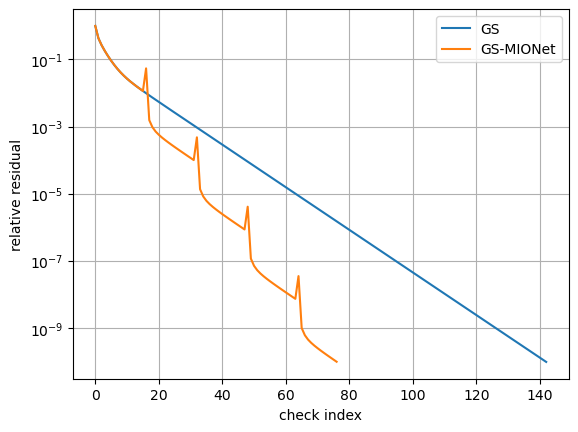

In [13]:
import matplotlib.pyplot as plt

plt.semilogy(info_gs["history"], label="GS")
plt.semilogy(info_hybrid["history"], label="GS-MIONet")
plt.xlabel("check index")
plt.ylabel("relative residual")
plt.legend()
plt.grid(True)
plt.show()